# Boston Marathons Performance X Weather Conditions

<img src="images/marathon_image.png" alt="Marathon image" title="Titre de l'image" width="300" />


## Welcome to our data project !

Our project investigates the relationship between Boston Marathon runner performance and weather conditions between 2000 and 2019.  
Specifically, we address three analytical questions :
1. How temperature correlate with the average finish time for Male and Female runners ? 
2. What is the historical difficulty of Boston marathons ?
3. Which age groups are most significantly affected by harsh weather conditions ?

To conduct this analysis, we built an integrated analytical database using five automated Airflow pipelines (three for data ingestion, one for data transformation and one for production data).
Our final database combines data from three sources :
- A GitHub repository containing the CSV files of the results of each Boston Marathon edition ;
- Wikidata to collect the dates of each Boston marathon edition ;
- Meteostat (a python library) to collect daily weather data for Boston from 2000 to 2019.

Want to see the result of our analysis ?
1. Execute each code cell in order.
2. Make sure to wait for each cell to finish running before launching the next one.
3. Enjoy ! 🏃‍♂️😉

## Authentication

In [1]:
import requests

headers = {
    "Accept": "application/json",
    "Content-Type": "application/json"
}
body = {
  "username": "airflow",
  "password": "airflow"
}
url = f"http://airflow-apiserver:8080/auth/token"
r = requests.post(url, headers=headers, json=body)

jwt_token = r.json().get("access_token")

## Create connections between Airflow and databases

In [2]:
import requests

# MongoDB
headers = {
    "Accept": "application/json",
    "Authorization": f"Bearer {jwt_token}",
    "Content-Type": "application/json"
}
body = {
    "connection_id": "mongo_default",
    "conn_type": "mongo",
    "description": "mongo_default",
    "host": "mongo",
    "login": "admin",
    "schema": "project",
    "port": 27017,
    "password": "admin",
    "extra":  "{\"srv\": false, \"ssl\": false, \"allow_insecure\": false, \"authSource\": \"admin\"}"
}
url = f"http://airflow-apiserver:8080/api/v2/connections"
r = requests.post(url, headers=headers, json=body)

# Postgres default
body = {
    "connection_id": "postgres_default",
    "conn_type": "postgres",
    "description": "postgres_default",
    "host": "postgres",
    "login": "airflow",
    "schema": "airflow",
    "port": 5432,
    "password": "airflow",
}
url = f"http://airflow-apiserver:8080/api/v2/connections"
r = requests.post(url, headers=headers, json=body)

# Postgres Staging Zone
body = {
    "connection_id": "postgres_staging",
    "conn_type": "postgres",
    "description": "postgres_staging",
    "host": "postgres",
    "login": "airflow",
    "schema": "staging",
    "port": 5432,
    "password": "airflow",
}
url = f"http://airflow-apiserver:8080/api/v2/connections"
r = requests.post(url, headers=headers, json=body)

# Postgres Production Zone
body = {
    "connection_id": "postgres_production",
    "conn_type": "postgres",
    "description": "postgres_production",
    "host": "postgres",
    "login": "airflow",
    "schema": "production",
    "port": 5432,
    "password": "airflow",
}
url = f"http://airflow-apiserver:8080/api/v2/connections"
r = requests.post(url, headers=headers, json=body)

## Ingestion Pipelines

In [3]:
import requests
from datetime import datetime, timezone
import pytz
import time

DAG_INGESTION_IDS = ["ingest_marathons", "ingest_marathons_date", "ingest_weather"]

headers = {
    "Accept": "application/json",
    "Authorization": f"Bearer {jwt_token}",
    "Content-Type": "application/json"
}

dag_runs = {}
for dag in DAG_INGESTION_IDS :
    dt = datetime.now(timezone.utc)
    logical_date = dt.strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3] + "Z"
    body = {
        "logical_date": logical_date,
        "conf": {}
    }
    url = f"http://airflow-apiserver:8080/api/v2/dags/{dag}/dagRuns"
    r = requests.post(url, headers=headers, json=body)
    resp_json = r.json()
    dag_runs[dag] = {
        "dag_run_id": resp_json["dag_run_id"],
        "dag_id" : resp_json["dag_id"],
        "state": ""
    }

all_done = False
while not all_done:
    print("The DAGs are running...")
    time.sleep(10)
    all_done = True
    for dag, info in dag_runs.items():
        if info["state"] not in ["success", "failed"]:
            url = f"http://airflow-apiserver:8080/api/v2/dags/{info['dag_id']}/dagRuns/{info['dag_run_id']}"
            r = requests.get(url, headers=headers)
            resp_json = r.json()
            state = resp_json["state"]
            info["state"] = state
            if state not in ["success", "failed"]:
                all_done = False    

for dag, info in dag_runs.items():
    if info["state"] == "success":
        print(f"DAG {dag} has been run successfully !")
    else:
        print(f"Error during the execution of the DAG {dag} !")

The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
The DAGs are running...
DAG ingest_marathons has been run successfully !
DAG ingest_marathons_date has been run successfully !
DAG ingest_weather has been run successfully !


## Staging pipeline

In [4]:
import requests
from datetime import datetime, timezone
import pytz
import time

headers = {
    "Accept": "application/json",
    "Authorization": f"Bearer {jwt_token}",
    "Content-Type": "application/json"
}

dag = "staging_data"
dt = datetime.now(timezone.utc)
logical_date = dt.strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3] + "Z"
body = {
    "logical_date": logical_date,
    "conf": {}
}
url = f"http://airflow-apiserver:8080/api/v2/dags/{dag}/dagRuns"
r = requests.post(url, headers=headers, json=body)

resp_json = r.json()
dag_run_id = resp_json["dag_run_id"]
dag_id = resp_json["dag_id"]
state = ""
while state != "success" and state != "failed":
    print("The DAG is running...")
    time.sleep(10)
    url = f"http://airflow-apiserver:8080/api/v2/dags/{dag_id}/dagRuns/{dag_run_id}"
    r = requests.get(url, headers=headers)
    resp_json = r.json()
    state = resp_json["state"] 

if state == "success":
    print("The DAG has been run successfully !")
else :
    print("Error during the execution of the DAG !")

The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG has been run successfully !


## Production pipeline

In [5]:
import requests
from datetime import datetime, timezone
import pytz
import time

headers = {
    "Accept": "application/json",
    "Authorization": f"Bearer {jwt_token}",
    "Content-Type": "application/json"
}

dag = "production_dag"
dt = datetime.now(timezone.utc)
logical_date = dt.strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3] + "Z"
body = {
    "logical_date": logical_date,
    "conf": {}
}
url = f"http://airflow-apiserver:8080/api/v2/dags/{dag}/dagRuns"
r = requests.post(url, headers=headers, json=body)

resp_json = r.json()
dag_run_id = resp_json["dag_run_id"]
dag_id = resp_json["dag_id"]
state = ""
while state != "success" and state != "failed":
    print("The DAG is running...")
    time.sleep(10)
    url = f"http://airflow-apiserver:8080/api/v2/dags/{dag_id}/dagRuns/{dag_run_id}"
    r = requests.get(url, headers=headers)
    resp_json = r.json()
    state = resp_json["state"]
    
if state == "success":
    print("The DAG has been run successfully !")
else :
    print("Error during the execution of the DAG !")

The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG is running...
The DAG has been run successfully !


## Execution of analytical request

Request 1 : How temperature correlate with the average finish time for Male and Female runners ?

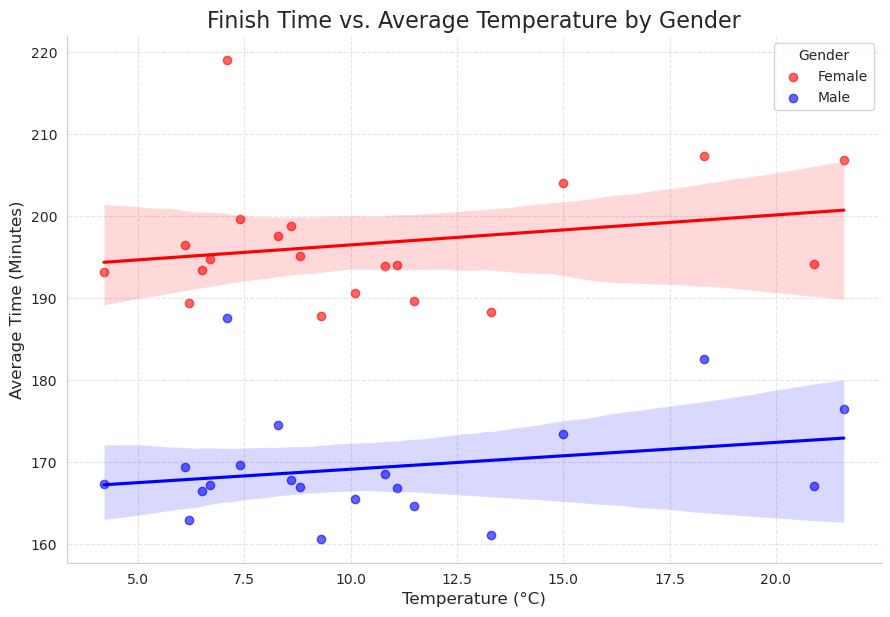

In [76]:
import psycopg2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="postgres",
    port=5432,
    database="production",
    user="airflow",
    password="airflow"
)

cur = conn.cursor()
cur.execute("""
    SELECT 
        d.year,
        l.city,
        w.averageTemperature,
        r.gender,
        AVG(f.time)::time(0) as average_finish_time
    FROM factraceresult f
    JOIN dimweather w ON f.weatherkey = w.weatherkey
    JOIN dimrunner r ON f.runnerkey = r.runnerkey
    JOIN dimdate d ON f.datekey = d.datekey
    JOIN dimlocation l ON f.locationkey = l.locationkey
    WHERE f.genderranking <= 1000
    GROUP BY 
        d.year, 
        l.city, 
        w.averageTemperature, 
        r.gender
    ORDER BY 
        w.averageTemperature DESC;
""")

rows = cur.fetchall()

""" Print results if needed
print(f"{'Year':<6} | {'City':<10} | {'Temperature':<10} | {'Gender':<6} | {'Avg Time'}")
print("-" * 60)

for row in rows:
    year, city, averageTemperature, gender, time = row
    print(f"{year:<6} | {city:<10} | {averageTemperature:<10} | {gender:<6} | {time}")
"""

cur.close()
conn.close()

df = pd.DataFrame(rows, columns=['Year', 'City', 'Temperature', 'Gender', 'Avg_Time'])

df = df[df['Gender'].isin(['M', 'F'])]

def time_to_minutes(t):
    if t is None:
        return None
    return t.hour * 60 + t.minute + t.second / 60.0

df['Time_Minutes'] = df['Avg_Time'].apply(time_to_minutes)

df['Temperature'] = df['Temperature'].astype(float)
df['Time_Minutes'] = df['Time_Minutes'].astype(float)

gender_label_map = {'M': 'Male', 'F': 'Female'}
df['Gender'] = df['Gender'].replace(gender_label_map)

custom_colors = {'Male': 'blue', 'Female': 'red'}

sns.lmplot(
    data=df,
    x='Temperature',
    y='Time_Minutes',
    hue='Gender',
    palette=custom_colors,
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.6},
    facet_kws={'legend_out': False} 
)

plt.title('Finish Time vs. Average Temperature by Gender', fontsize=16)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Average Time (Minutes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Request 2 : What is the historical difficulty of Boston marathons ?


Year   | Temp (°C)  | Wind     | Rain     | Pressure   | Difficulty
------------------------------------------------------------
2000   | 6.7        | 22.7     | 0.0      | 1023.7     | Normal
2001   | 6.1        | 15.5     | 0.0      | 1007.1     | Slow (Hard)
2002   | 11.1       | 13.0     | 2.3      | 1015.3     | Normal
2003   | 8.3        | 15.1     | 2.0      | 1017.0     | Slow (Hard)
2004   | 18.3       | 24.1     | 0.0      | 1014.8     | Slow (Hard)
2005   | 15.0       | 16.2     | 0.0      | 1017.2     | Slow (Hard)
2006   | 8.6        | 16.9     | 0.3      | 1008.0     | Normal
2007   | 7.4        | 37.8     | 23.6     | 986.8      | Slow (Hard)
2008   | 8.8        | 11.2     | 0.0      | 1027.8     | Normal
2009   | 6.5        | 22.3     | 2.3      | 1024.5     | Fast (Easy)
2010   | 10.1       | 19.8     | 0.0      | 1011.1     | Fast (Easy)
2011   | 11.5       | 23.4     | 0.0      | 1012.4     | Fast (Easy)
2012   | 21.6       | 15.5     | 0.0      | 1014.2     | Slow 

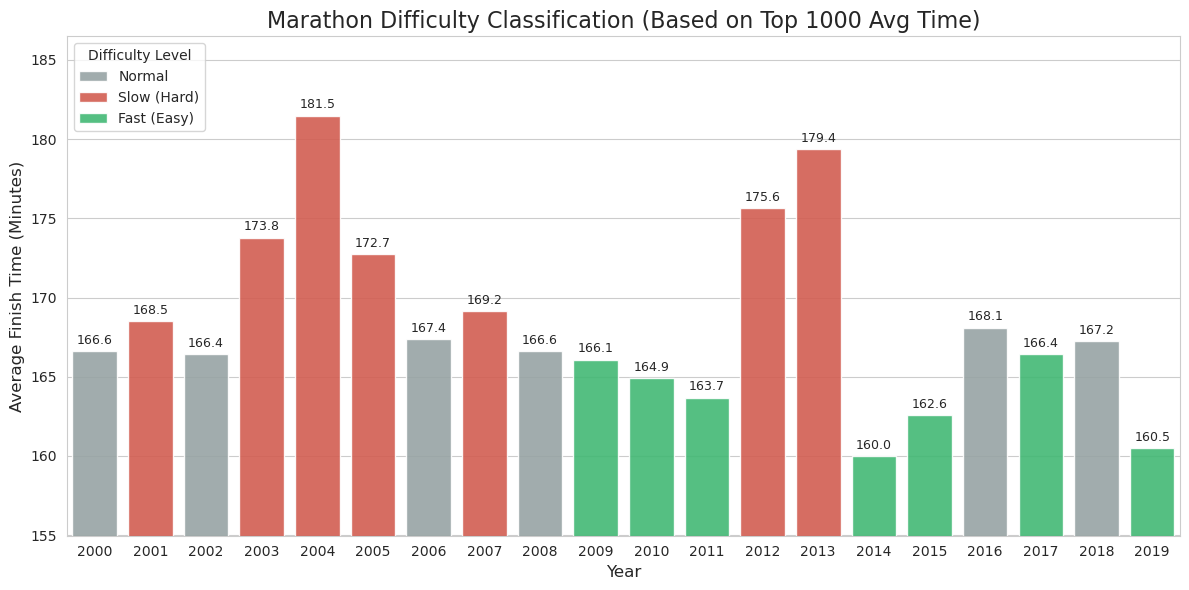

In [77]:
import psycopg2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="postgres",
    port=5432,
    database="production",
    user="airflow",
    password="airflow"
)

query = """
    SELECT 
        d.year,
        AVG(f.time)::time(0) as avg_time,
        w.averageTemperature as temp,
        w.windSpeed as wind,
        w.precipitation as rain,
        w.pressure as pressure
    FROM factraceresult f
    JOIN dimweather w ON f.weatherkey = w.weatherkey
    JOIN dimdate d ON f.datekey = d.datekey
    WHERE f.overallranking <= 1000
    GROUP BY 
        d.year, 
        w.averageTemperature, 
        w.windSpeed, 
        w.precipitation, 
        w.pressure
    ORDER BY d.year;
"""

cur = conn.cursor()
cur.execute(query)
rows = cur.fetchall()
cur.close()
conn.close()

cols = ['Year', 'Avg_Time', 'Temp', 'Wind', 'Rain', 'Pressure']
df = pd.DataFrame(rows, columns=cols)

def time_to_minutes(t):
    if t is None: return None
    return t.hour * 60 + t.minute + t.second / 60.0

df['Time_Minutes'] = df['Avg_Time'].apply(time_to_minutes)

numeric_cols = ['Temp', 'Wind', 'Rain', 'Pressure']
for col in numeric_cols:
    df[col] = df[col].astype(float)

lower = df['Time_Minutes'].quantile(0.33)
upper = df['Time_Minutes'].quantile(0.66)

def get_difficulty(t):
    if t < lower: return 'Fast (Easy)'
    elif t > upper: return 'Slow (Hard)'
    return 'Normal'

df['Difficulty'] = df['Time_Minutes'].apply(get_difficulty)

print("\n" + "="*60)
print(f"{'Year':<6} | {'Temp (°C)':<10} | {'Wind':<8} | {'Rain':<8} | {'Pressure':<10} | {'Difficulty'}")
print("-" * 60)

for index, row in df.iterrows():
    print(f"{int(row['Year']):<6} | {row['Temp']:<10.1f} | {row['Wind']:<8.1f} | {row['Rain']:<8.1f} | {row['Pressure']:<10.1f} | {row['Difficulty']}")
print("="*60 + "\n")


sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

difficulty_colors = {'Fast (Easy)': '#2ecc71', 'Normal': '#95a5a6', 'Slow (Hard)': '#e74c3c'}

ax = sns.barplot(
    data=df, 
    x='Year', 
    y='Time_Minutes', 
    hue='Difficulty', 
    palette=difficulty_colors, 
    dodge=False, 
    alpha=0.9
)

plt.title('Marathon Difficulty Classification (Based on Top 1000 Avg Time)', fontsize=16)
plt.ylabel('Average Finish Time (Minutes)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.ylim(df['Time_Minutes'].min() - 5, df['Time_Minutes'].max() + 5)
plt.legend(title='Difficulty Level', loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Request 3 : Which age groups are most significantly affected by harsh weather conditions

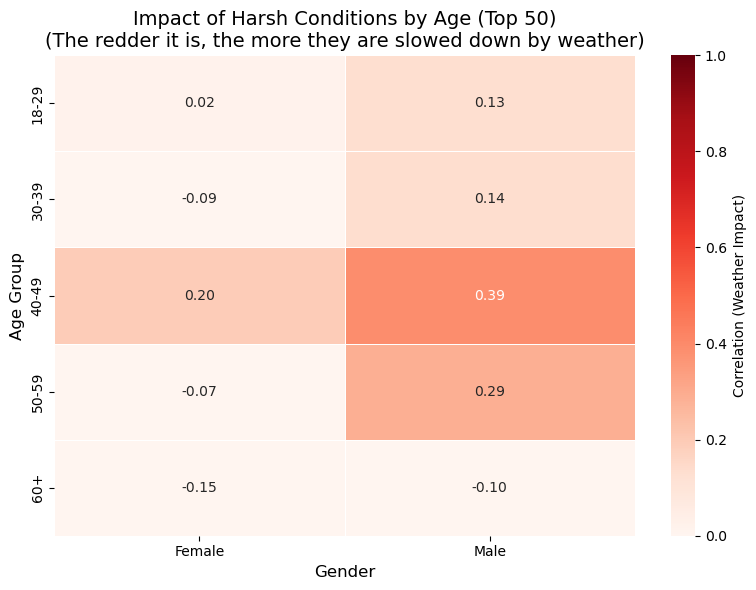

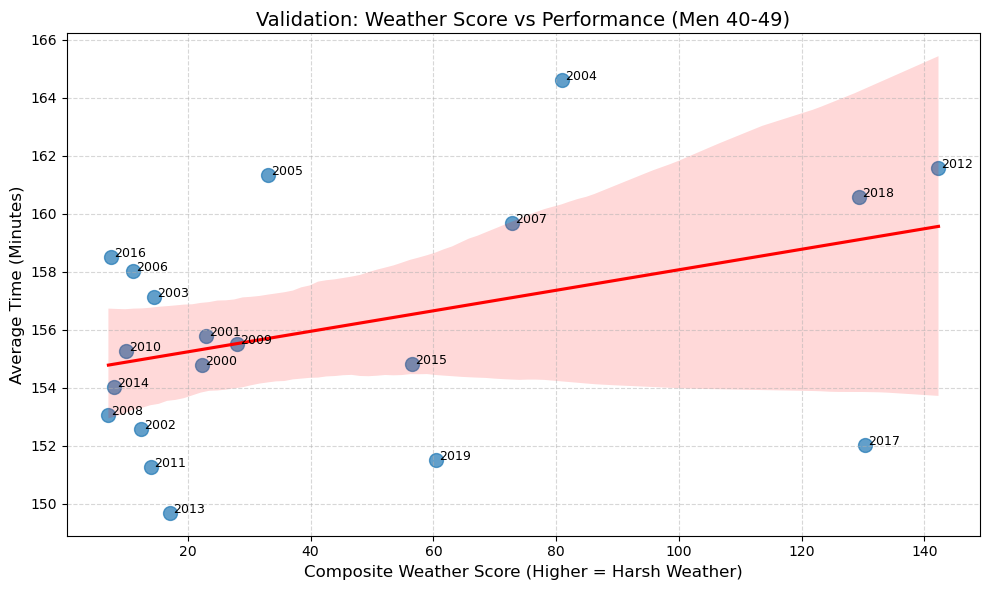

In [4]:
import psycopg2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONNECTION ---
conn = psycopg2.connect(
    host="postgres",
    port=5432,
    database="production",
    user="airflow",
    password="airflow"
)

# We classify runners into standard age groups for analysis.
# Then, we take the Top 50 of each group.

query = """
    WITH RunnerData AS (
        SELECT 
            d.year,
            r.gender,
            -- CREATING AGE GROUPS HERE
            CASE 
                WHEN r.age < 30 THEN '18-29'
                WHEN r.age BETWEEN 30 AND 39 THEN '30-39'
                WHEN r.age BETWEEN 40 AND 49 THEN '40-49'
                WHEN r.age BETWEEN 50 AND 59 THEN '50-59'
                WHEN r.age >= 60 THEN '60+'
                ELSE 'Unknown'
            END as age_group_derived,
            f.time,
            w.averageTemperature as temp,
            w.windSpeed as wind,
            w.precipitation as rain,
            w.pressure as pressure
        FROM factraceresult f
        JOIN dimweather w ON f.weatherkey = w.weatherkey
        JOIN dimrunner r ON f.runnerkey = r.runnerkey
        JOIN dimdate d ON f.datekey = d.datekey
        WHERE r.age IS NOT NULL 
          AND r.age > 18 -- Optional filter to exclude children/errors
    ),
    RankedRunners AS (
        SELECT 
            *,
            -- Ranking runners within their NEW age group
            ROW_NUMBER() OVER (
                PARTITION BY year, gender, age_group_derived 
                ORDER BY time ASC
            ) as ranking
        FROM RunnerData
        WHERE age_group_derived != 'Unknown'
    )
    SELECT 
        year,
        gender,
        age_group_derived as agegroup,
        AVG(EXTRACT(EPOCH FROM time)/60) as avg_time_minutes,
        temp,
        wind,
        rain,
        pressure
    FROM RankedRunners
    WHERE ranking <= 50 -- Keeping only the elite of each category
    GROUP BY 
        year, gender, age_group_derived, temp, wind, rain, pressure
    ORDER BY year, age_group_derived, gender;
"""

cur = conn.cursor()
cur.execute(query)
rows = cur.fetchall()
cur.close()
conn.close()


cols = ['Year', 'Gender', 'AgeGroup', 'Avg_Time', 'Temp', 'Wind', 'Rain', 'Pressure']
df = pd.DataFrame(rows, columns=cols)

for col in ['Avg_Time', 'Temp', 'Wind', 'Rain', 'Pressure']:
    df[col] = df[col].astype(float)


# Formula: (Temperature - 10°C)² + (Wind * 0.5) + (Rain * 2)
def calculate_weather_stress(row):
    temp_stress = (row['Temp'] - 10) ** 2
    wind_stress = row['Wind'] * 0.5
    rain_stress = row['Rain'] * 2
    return temp_stress + wind_stress + rain_stress

df['Weather_Score'] = df.apply(calculate_weather_stress, axis=1)

df['Gender'] = df['Gender'].map({'M': 'Male', 'F': 'Female'})


# We measure correlation between "Weather Score" and "Avg Time".
# A strong correlation (close to 1) means the age group slows down significantly when weather is bad.
correlation_data = []
age_groups = sorted(df['AgeGroup'].unique())
genders = ['Male', 'Female']

for gender in genders:
    for age in age_groups:
        subset = df[(df['Gender'] == gender) & (df['AgeGroup'] == age)]
        
        corr = subset['Weather_Score'].corr(subset['Avg_Time'])
        correlation_data.append({'Gender': gender, 'AgeGroup': age, 'Resilience_Score': corr})

corr_df = pd.DataFrame(correlation_data)

heatmap_data = corr_df.pivot(index='AgeGroup', columns='Gender', values='Resilience_Score')

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    cmap='Reds',
    fmt=".2f", 
    vmin=0, 
    vmax=1,
    linewidths=.5,
    cbar_kws={'label': 'Correlation (Weather Impact)'}
)

plt.title('Impact of Harsh Conditions by Age (Top 50)\n(The redder it is, the more they are slowed down by weather)', fontsize=14)
plt.ylabel('Age Group', fontsize=12)
plt.xlabel('Gender', fontsize=12)
plt.tight_layout()
plt.show()

# Scatter Plot for 40-49 age group (highest p-value)
# To visually verify the trend on a specific group
target_group = df[(df['Gender'] == 'Male') & (df['AgeGroup'] == '40-49')]

if not target_group.empty:
    plt.figure(figsize=(10, 6))
    sns.regplot(
        data=target_group,
        x='Weather_Score',
        y='Avg_Time',
        scatter_kws={'s': 100, 'alpha': 0.7},
        line_kws={'color': 'red'}
    )

    plt.title('Validation: Weather Score vs Performance (Men 40-49)', fontsize=14)
    plt.xlabel('Composite Weather Score (Higher = Harsh Weather)', fontsize=12)
    plt.ylabel('Average Time (Minutes)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    for i, row in target_group.iterrows():
        plt.text(row['Weather_Score']+0.5, row['Avg_Time'], str(int(row['Year'])), fontsize=9)

    plt.tight_layout()
    plt.show()